In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Input, Model, layers
from tensorflow.keras.layers import Dense, Concatenate
from tensorflow.keras.regularizers import Regularizer
from tensorflow.keras import regularizers
import scipy.stats as ss
from scipy.linalg import null_space
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

/Users/alamson/local/miniconda/envs/elektrum/lib/python3.7/site-packages/tensorflow/python/framework/dtypes.py:516: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
/Users/alamson/local/miniconda/envs/elektrum/lib/python3.7/site-packages/tensorflow/python/framework/dtypes.py:517: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
/Users/alamson/local/miniconda/envs/elektrum/lib/python3.7/site-packages/tensorflow/python/framework/dtypes.py:518: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16, 1)])
/Users/alamson/l

In [2]:
# Load the data from csv files
df = pd.read_csv("../test_files/test_4ring/test_4ring.csv")
ka_mat = np.loadtxt("../test_files/test_4ring/test_4ring_ka_mat.nptxt")
ka_contrib = np.loadtxt("../test_files/test_4ring/test_4ring_rate_contrib_mat.nptxt")
x = df["seq"].values
y = df["raw_activity"].values

enc = OneHotEncoder(categories=[["A", "B"]], sparse=False)

# Encode sequences as one-hot vectors
n_samples = len(x)
seq_length = len(x[0])  # Assuming all sequences have the same length
flat = np.array([list(seq) for seq in x]).flatten()[:, None]
encoded = enc.fit_transform(flat)
x = encoded.reshape(n_samples, seq_length, 2)  # shape: (n_samples, seq_length, 2)
print(ka_mat)

[[0. 1. 0. 1. 0. 0. 1.]
 [0. 1. 0. 0. 1. 0. 1.]
 [0. 0. 1. 0. 1. 0. 1.]
 [0. 1. 0. 1. 0. 1. 0.]
 [1. 0. 0. 1. 0. 0. 1.]
 [1. 0. 0. 0. 1. 0. 1.]
 [1. 0. 0. 1. 0. 1. 0.]
 [1. 0. 1. 0. 0. 0. 1.]
 [1. 0. 1. 0. 0. 1. 0.]
 [1. 0. 1. 0. 1. 0. 0.]]


In [3]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=777
)

In [4]:
# Regularize based on the log_rate layer
class SumRegularizer(Regularizer):
    def __init__(self, coeff=1e-4):
        self.coeff = coeff  # lambda

    def __call__(self, x):
        # Just sum the raw values (NOT abs or square)
        return self.coeff * tf.reduce_sum(x)

    def get_config(self):
        return {"coeff": self.coeff}


inputs = layers.Input(shape=(seq_length, 2))  # one-hot encoded 'A'/'B' per position
flat = layers.Flatten()(inputs)  # flatten the input
log_rates = layers.Dense(
    7, activation="linear", name="log_rates", kernel_regularizer=SumRegularizer(coeff=1e-6)
)(flat)  # hidden layer
KA_terms = layers.Lambda(
    lambda x: tf.nn.softmax(
        tf.matmul(x, tf.constant(ka_mat, dtype=tf.float32), transpose_b=True)
    ),
    name="KA_terms",
)(log_rates)
print(ka_mat.shape)
print(ka_contrib.shape)

# Corrected Lambda for contrib_KA_terms
contrib_KA_terms = layers.Lambda(
    lambda x: tf.matmul(x, tf.constant(ka_contrib, dtype=tf.float32), transpose_b=True),
    name="contrib_KA_terms",
)(KA_terms)
exp_rates = layers.Lambda(lambda x: tf.exp(x), name="exp_log_rates")(log_rates)
output = layers.Dot(axes=1, name="dot_output")([contrib_KA_terms, exp_rates])
model = Model(inputs=inputs, outputs=output)


model.compile(optimizer="adam", loss="mse")

# Train the model
hist = model.fit(
    x_train, y_train, epochs=500, batch_size=32, validation_data=(x_test, y_test)
)


Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor
(10, 7)
(7, 10)
Train on 1600 samples, validate on 400 samples
Epoch 1/500
1600/1600 [==============================] - 0s 123us/sample - loss: 9.2735e-04 - val_loss: 6.0976e-04
Epoch 2/500
  32/1600 [..............................] - ETA: 0s - loss: 3.2593e-04

2025-07-29 11:36:34.791538: I tensorflow/core/platform/cpu_feature_guard.cc:142] Your CPU supports instructions that this TensorFlow binary was not compiled to use: AVX2 FMA


1600/1600 [==============================] - 0s 28us/sample - loss: 4.0648e-04 - val_loss: 2.6983e-04
Epoch 3/500
1600/1600 [==============================] - 0s 23us/sample - loss: 1.7926e-04 - val_loss: 1.1955e-04
Epoch 4/500
1600/1600 [==============================] - 0s 23us/sample - loss: 8.2123e-05 - val_loss: 5.4491e-05
Epoch 5/500
1600/1600 [==============================] - 0s 23us/sample - loss: 3.8844e-05 - val_loss: 2.5377e-05
Epoch 6/500
1600/1600 [==============================] - 0s 24us/sample - loss: 1.9282e-05 - val_loss: 1.2742e-05
Epoch 7/500
1600/1600 [==============================] - 0s 26us/sample - loss: 9.7391e-06 - val_loss: 5.8803e-06
Epoch 8/500
1600/1600 [==============================] - 0s 24us/sample - loss: 5.2002e-06 - val_loss: 2.9974e-06
Epoch 9/500
1600/1600 [==============================] - 0s 22us/sample - loss: 2.9932e-06 - val_loss: 1.6752e-06
Epoch 10/500
1600/1600 [==============================] - 0s 23us/sample - loss: 1.8620e-06 - val_lo

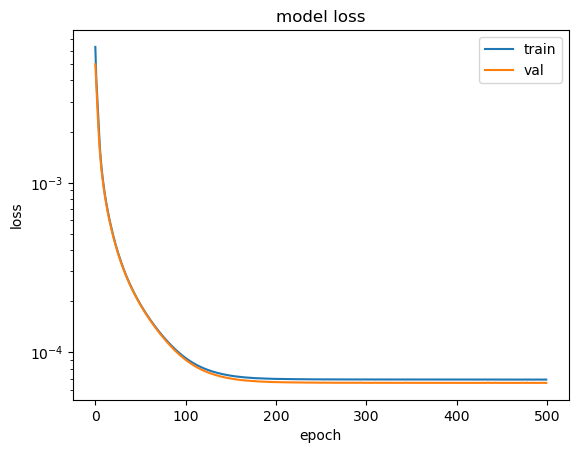

In [14]:
plt.plot(hist.history["loss"])
plt.plot(hist.history["val_loss"])
plt.title("model loss")
plt.ylabel("loss")
plt.xlabel("epoch")
plt.legend(["train", "val"])
plt.yscale("log")

In [15]:
# Regularize based on the rates with L1 norm

inputs = layers.Input(shape=(seq_length, 2))  # one-hot encoded 'A'/'B' per position
flat = layers.Flatten()(inputs)  # flatten the input
log_rates = layers.Dense(
    7, activation="linear", name="log_rates")(flat)  # hidden layer
KA_terms = layers.Lambda(
    lambda x: tf.nn.softmax(
        tf.matmul(x, tf.constant(ka_mat, dtype=tf.float32), transpose_b=True)
    ),
    name="KA_terms",
)(log_rates)
print(ka_mat.shape)
print(ka_contrib.shape)

# Corrected Lambda for contrib_KA_terms
contrib_KA_terms = layers.Lambda(
    lambda x: tf.matmul(x, tf.constant(ka_contrib, dtype=tf.float32), transpose_b=True),
    name="contrib_KA_terms",
)(KA_terms)
exp_rates = layers.Lambda(lambda x: tf.exp(x), name="exp_log_rates")(log_rates)
output = layers.Dot(axes=1, name="dot_output")([contrib_KA_terms, exp_rates])
model = Model(inputs=inputs, outputs=output)

# ----- ADD CUSTOM L1 LOSS ON LAMBDA OUTPUT -----
lambda_output = model.get_layer('exp_log_rates').output  # output of Lambda layer
l1_penalty = 1e-3 * tf.reduce_sum(tf.abs(lambda_output))

# Base loss
base_loss = 'mse'

# Combine them in compile() by using model.add_loss (TF2) is unavailable,
# so we instead wrap into a custom loss function:
def custom_loss(y_true, y_pred):
    return tf.reduce_mean(tf.square(y_true - y_pred)) + l1_penalty


model.compile(optimizer="adam", loss="mse")

# Train the model
hist = model.fit(
    x_train, y_train, epochs=500, batch_size=32, validation_data=(x_test, y_test)
)


(10, 7)
(7, 10)
Train on 1600 samples, validate on 400 samples
Epoch 1/500
1600/1600 [==============================] - 0s 131us/sample - loss: 0.0033 - val_loss: 0.0011
Epoch 2/500
1600/1600 [==============================] - 0s 26us/sample - loss: 9.1709e-04 - val_loss: 6.8683e-04
Epoch 3/500
1600/1600 [==============================] - 0s 24us/sample - loss: 6.4403e-04 - val_loss: 5.0489e-04
Epoch 4/500
1600/1600 [==============================] - 0s 25us/sample - loss: 4.7517e-04 - val_loss: 3.6933e-04
Epoch 5/500
1600/1600 [==============================] - 0s 24us/sample - loss: 3.4902e-04 - val_loss: 2.7188e-04
Epoch 6/500
1600/1600 [==============================] - 0s 44us/sample - loss: 2.5886e-04 - val_loss: 1.9932e-04
Epoch 7/500
1600/1600 [==============================] - 0s 25us/sample - loss: 1.9239e-04 - val_loss: 1.4782e-04
Epoch 8/500
1600/1600 [==============================] - 0s 24us/sample - loss: 1.4368e-04 - val_loss: 1.1064e-04
Epoch 9/500
1600/1600 [=========

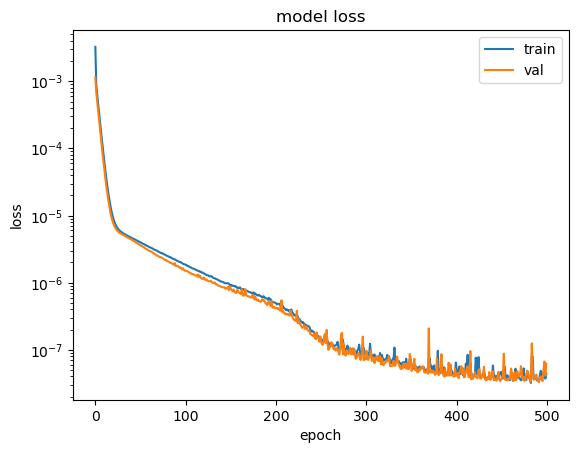

In [16]:
plt.plot(hist.history["loss"])
plt.plot(hist.history["val_loss"])
plt.title("model loss")
plt.ylabel("loss")
plt.xlabel("epoch")
plt.legend(["train", "val"])
plt.yscale("log")

In [8]:
np.set_printoptions(linewidth=np.inf)
layer = model.get_layer("log_rates")  # or model.layers[0]
weights, biases = layer.get_weights()
# print(weights.shape, biases.shape)
# print(np.max(np.exp(weights.T), axis=1))

test_arr = np.zeros(14)
test_arr[::2] = 1.0
print("Test array:", test_arr)
weights = np.array(weights)
print("biases")
print(np.exp(biases))
print("Weights shape:", weights.shape)
print("Weights:", weights)
results = np.matmul(test_arr, weights) + biases
print("Results for test array:", results)
print("Rates:", np.exp(results))

Test array: [1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0.]
biases
[0.83951855 1.2998673  0.9097885  1.0497642  0.94253516 1.1106626  0.8982085 ]
Weights shape: (14, 7)
Weights: [[ 0.05816328  0.7343137   0.2549177  -0.18569335  0.28666788 -0.23348458  0.1625256 ]
 [-0.33178777 -0.20500094 -0.3316815  -0.19177014  0.33769667  0.03686038 -0.14064993]
 [-0.20947681  0.48397312  0.36745107 -0.06805003  0.09537982 -0.21747464  0.31116244]
 [-0.43886235 -0.43207496 -0.601966   -0.15523785  0.13718504  0.6048993  -0.12745863]
 [-0.02793721 -0.13975884  0.35498458  0.16138594  0.15571485  0.2155767   0.35264564]
 [ 0.11402677  0.1320691   0.28840092 -0.08618472 -0.36386442  0.24173383  0.02277337]
 [ 0.13620277 -0.3276522   0.2182143   0.02098127 -0.02211114 -0.44548124 -0.07808975]
 [ 0.27662268  0.49126083  0.2293749   0.04047313 -0.55617696  0.6148524   0.36324733]
 [ 0.10904579 -0.01335035 -0.09361847 -0.51613605 -0.33081615 -0.2649879  -0.5241863 ]
 [-0.0721694   0.12008848 -0.29833555 -0.08

In [9]:
k = np.exp(results)
rate_matrix = -np.array(
    [
        [-k[0], k[1], 0, k[6]],
        [
            k[0],
            -(k[1] + k[2]),
            k[3],
            0,
        ],
        [0, k[2], -(k[3] + k[4]), k[5]],
        [0, 0, k[4], -(k[5] + k[6])],
    ]
)

np.linalg.eig(rate_matrix)
print("Rate matrix:")
kernel = null_space(rate_matrix)
kernel = kernel / np.sum(kernel)  # Normalize the kernel
kernel[-1] * k[-1]

Rate matrix:


array([0.09986744])

In [10]:
x = np.array([[1, 0]] * 7).reshape(1, 7, 2)  # Example input
print("Input x:", x)
# print(x)
# print("Input x shape:", x.shape)
y = model.predict(x)
print("Predicted y:", y)
x2 = np.array([[1, 0]] * 7).reshape(1, 7, 2)  # Example input
x2[0, 0] = np.array([0, 1])  # Change the first position to 'B'
print("Input x2:", x2)
y2 = model.predict(x2)
print("Predicted y2:", y2)

Input x: [[[1 0]
  [1 0]
  [1 0]
  [1 0]
  [1 0]
  [1 0]
  [1 0]]]
Predicted y: [[0.09986745]]
Input x2: [[[0 1]
  [1 0]
  [1 0]
  [1 0]
  [1 0]
  [1 0]
  [1 0]]]
Predicted y2: [[0.07141193]]


In [11]:
from tensorflow.keras import Model

activation = Model(inputs=model.input, outputs=model.get_layer("log_rates").output)
activation_output = activation.predict(x)
print("Activation output:", np.exp(activation_output))

Activation output: [[0.9416532  2.2245784  2.3570724  1.459676   0.69407797 0.80821085 1.4880415 ]]


In [12]:
from tensorflow.keras import Model

activation = Model(inputs=model.input, outputs=model.get_layer("log_rates").output)
activation_output = activation.predict(x2)
print("Activation output:", np.exp(activation_output))

Activation output: [[0.6375839  0.8695779  1.3110404  1.4508326  0.73041517 1.0590926  1.0988733 ]]


In [13]:
# Regularize based on the rates with L1 norm on the exponent of the rate matrix
class LogRateRegularize(Regularizer):
    def __init__(self, coeff=1e-6):
        self.coeff = coeff

    def __call__(self, x):
        # Here x is the ACTIVATION output of the layer
        # Example: L1 norm on activations
        return self.coeff * tf.reduce_sum(tf.exp(x))

    def get_config(self):
        return {'coeff': float(self.coeff)}

inputs = layers.Input(shape=(seq_length, 2))  # one-hot encoded 'A'/'B' per position
flat = layers.Flatten()(inputs)  # flatten the input
log_rates = layers.Dense(
    7, activation="linear", name="log_rates", activity_regularizer=LogRateRegularize(1e-4))(flat)  # hidden layer
KA_terms = layers.Lambda(
    lambda x: tf.nn.softmax(
        tf.matmul(x, tf.constant(ka_mat, dtype=tf.float32), transpose_b=True)
    ),
    name="KA_terms",
)(log_rates)
print(ka_mat.shape)
print(ka_contrib.shape)

# Corrected Lambda for contrib_KA_terms
contrib_KA_terms = layers.Lambda(
    lambda x: tf.matmul(x, tf.constant(ka_contrib, dtype=tf.float32), transpose_b=True),
    name="contrib_KA_terms",
)(KA_terms)
exp_rates = layers.Lambda(lambda x: tf.exp(x), name="exp_log_rates")(log_rates)
output = layers.Dot(axes=1, name="dot_output")([contrib_KA_terms, exp_rates])
model = Model(inputs=inputs, outputs=output)


model.compile(optimizer="adam", loss="mse")

# Train the model
hist = model.fit(
    x_train, y_train, epochs=500, batch_size=32, validation_data=(x_test, y_test)
)


(10, 7)
(7, 10)
Train on 1600 samples, validate on 400 samples
Epoch 1/500
1600/1600 [==============================] - 0s 112us/sample - loss: 0.0063 - val_loss: 0.0050
Epoch 2/500
1600/1600 [==============================] - 0s 25us/sample - loss: 0.0042 - val_loss: 0.0038
Epoch 3/500
1600/1600 [==============================] - 0s 23us/sample - loss: 0.0033 - val_loss: 0.0030
Epoch 4/500
1600/1600 [==============================] - 0s 24us/sample - loss: 0.0025 - val_loss: 0.0023
Epoch 5/500
1600/1600 [==============================] - 0s 24us/sample - loss: 0.0020 - val_loss: 0.0018
Epoch 6/500
1600/1600 [==============================] - 0s 24us/sample - loss: 0.0016 - val_loss: 0.0015
Epoch 7/500
1600/1600 [==============================] - 0s 24us/sample - loss: 0.0014 - val_loss: 0.0013
Epoch 8/500
1600/1600 [==============================] - 0s 23us/sample - loss: 0.0012 - val_loss: 0.0012
Epoch 9/500
1600/1600 [==============================] - 0s 23us/sample - loss: 0.0011 -

Test array: [1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0.]
biases
[0.60789514 0.3669583  0.6246078  0.2852975  0.6395971  0.26465896 0.65938205]
Weights shape: (14, 7)
Weights: [[-0.12022392 -1.35743     0.22847159 -1.72163    -0.17044234 -1.9716544  -0.08297739]
 [-0.4713996  -0.93781626 -0.12594901 -0.328483   -0.5278354  -0.98041445 -0.43707466]
 [ 0.01451555 -0.7339111   0.10835066 -1.9135215  -0.12998104 -1.2470833   0.02745249]
 [-0.8677873  -0.30740333 -0.78018725 -0.38394397 -1.0096992  -0.55861235 -0.845796  ]
 [-0.56514925 -1.4402804  -0.42824352 -1.3366041  -0.08553375 -1.0091739   0.05904144]
 [-1.067292   -0.55633724 -0.9322477  -1.0400778  -0.57866216 -0.6131857  -0.43218172]
 [ 0.34312642 -1.9521393  -0.1460075  -1.4967008   0.07923818 -1.2906666   0.08485762]
 [-0.72750866  0.10828939 -1.2220404  -0.00373232 -0.96065664 -0.09955694 -0.94914925]
 [ 0.03085363 -1.4211354   0.1133414  -1.2142484  -0.01938234 -1.6462836  -0.62734556]
 [-0.4795283  -0.19229338 -0.3985957  -0.96

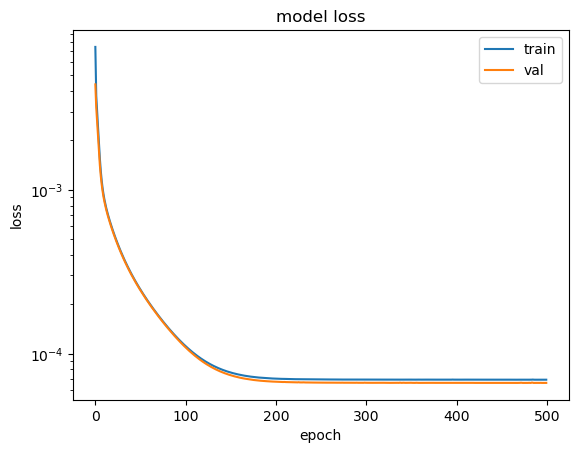

In [42]:
plt.plot(hist.history["loss"])
plt.plot(hist.history["val_loss"])
plt.title("model loss")
plt.ylabel("loss")
plt.xlabel("epoch")
plt.legend(["train", "val"])
plt.yscale("log")
np.set_printoptions(linewidth=np.inf)
layer = model.get_layer("log_rates")  # or model.layers[0]
weights, biases = layer.get_weights()
# print(weights.shape, biases.shape)
# print(np.max(np.exp(weights.T), axis=1))

test_arr = np.zeros(14)
test_arr[::2] = 1.0
print("Test array:", test_arr)
weights = np.array(weights)
print("biases")
print(np.exp(biases))
print("Weights shape:", weights.shape)
print("Weights:", weights)
results = np.matmul(test_arr, weights) + biases
print("Results for test array:", results)
print("Rates:", np.exp(results))

In [52]:
# Regularize based on the rates with L1 norm on the exponent of the rate matrix
class LogRateRegularize(Regularizer):
    def __init__(self, coeff=1e-4):
        self.coeff = coeff

    def __call__(self, x):
        # Here x is the ACTIVATION output of the layer
        # Example: L1 norm on activations
        return self.coeff * tf.reduce_sum(tf.exp(x))

    def get_config(self):
        return {'coeff': float(self.coeff)}

inputs = layers.Input(shape=(seq_length, 2))  # one-hot encoded 'A'/'B' per position
flat = layers.Flatten()(inputs)  # flatten the input
log_rates = layers.Dense(
    7, activation="linear", name="log_rates", kernel_regularizer=LogRateRegularize(1e-7))(flat)  # hidden layer
KA_terms = layers.Lambda(
    lambda x: tf.nn.softmax(
        tf.matmul(x, tf.constant(ka_mat, dtype=tf.float32), transpose_b=True)
    ),
    name="KA_terms",
)(log_rates)
print(ka_mat.shape)
print(ka_contrib.shape)

# Corrected Lambda for contrib_KA_terms
contrib_KA_terms = layers.Lambda(
    lambda x: tf.matmul(x, tf.constant(ka_contrib, dtype=tf.float32), transpose_b=True),
    name="contrib_KA_terms",
)(KA_terms)
exp_rates = layers.Lambda(lambda x: tf.exp(x), name="exp_log_rates")(log_rates)
output = layers.Dot(axes=1, name="dot_output")([contrib_KA_terms, exp_rates])
model = Model(inputs=inputs, outputs=output)


model.compile(optimizer="adam", loss="mse")

# Train the model
hist = model.fit(
    x_train, y_train, epochs=1000, batch_size=16, validation_data=(x_test, y_test)
)


(10, 7)
(7, 10)
Train on 1600 samples, validate on 400 samples
Epoch 1/1000
1600/1600 [==============================] - 1s 400us/sample - loss: 0.0018 - val_loss: 0.0011
Epoch 2/1000
1600/1600 [==============================] - 0s 51us/sample - loss: 6.3922e-04 - val_loss: 4.1088e-04
Epoch 3/1000
1600/1600 [==============================] - 0s 49us/sample - loss: 2.5917e-04 - val_loss: 1.7191e-04
Epoch 4/1000
1600/1600 [==============================] - 0s 50us/sample - loss: 1.1801e-04 - val_loss: 8.0014e-05
Epoch 5/1000
1600/1600 [==============================] - 0s 51us/sample - loss: 6.0432e-05 - val_loss: 4.3007e-05
Epoch 6/1000
1600/1600 [==============================] - 0s 88us/sample - loss: 3.5356e-05 - val_loss: 2.6718e-05
Epoch 7/1000
1600/1600 [==============================] - 0s 50us/sample - loss: 2.3528e-05 - val_loss: 1.9124e-05
Epoch 8/1000
1600/1600 [==============================] - 0s 51us/sample - loss: 1.7895e-05 - val_loss: 1.5334e-05
Epoch 9/1000
1600/1600 [

Test array: [1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0.]
biases
[  6.1840467   1.0835075  70.16879     1.50368   155.38028     1.6991165 122.17404  ]
Weights shape: (14, 7)
Weights: [[-0.4975477  -4.3642187  -0.87140936 -4.2826614  -0.93092245 -4.3077307  -0.62618846]
 [-0.7263601  -4.4239135  -1.039107   -4.309299   -1.1930679  -4.320176   -1.6248356 ]
 [-0.5313787  -4.376569   -0.69682825 -4.277525   -0.67693824 -4.3141747  -0.44098285]
 [-0.88170445 -4.429627   -1.3176562  -4.3096685  -1.6951619  -4.2975335  -2.4202442 ]
 [-0.46966735 -4.372551   -0.7857185  -4.290242   -0.70883554 -4.3192463  -0.705602  ]
 [-0.8106022  -4.3917084  -1.1719608  -4.28342    -1.5761243  -4.3045607  -1.4702076 ]
 [-0.49284568 -4.387584   -0.5370416  -4.316861   -0.47946915 -4.3029404  -0.57463515]
 [-0.8840406  -4.3941383  -1.7369283  -4.2821655  -2.531844   -4.3134513  -1.8912812 ]
 [-0.50174296 -4.38596    -0.6536751  -4.27906    -0.70860296 -4.2952337  -0.82942766]
 [-0.8328438  -4.3997293  -1.3741254

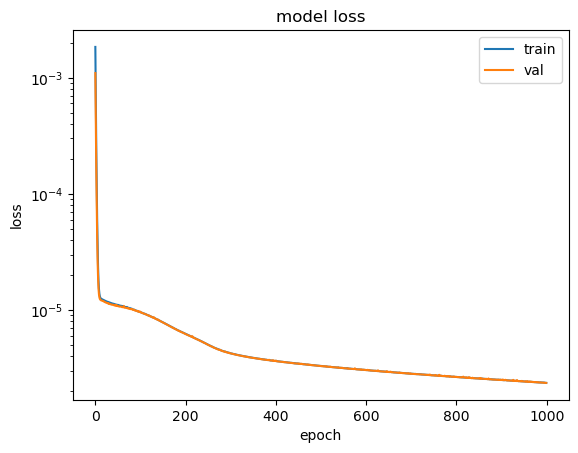

In [53]:
plt.plot(hist.history["loss"])
plt.plot(hist.history["val_loss"])
plt.title("model loss")
plt.ylabel("loss")
plt.xlabel("epoch")
plt.legend(["train", "val"])
plt.yscale("log")
np.set_printoptions(linewidth=np.inf)
layer = model.get_layer("log_rates")  # or model.layers[0]
weights, biases = layer.get_weights()
# print(weights.shape, biases.shape)
# print(np.max(np.exp(weights.T), axis=1))

test_arr = np.zeros(14)
test_arr[::2] = 1.0
print("Test array:", test_arr)
weights = np.array(weights)
print("biases")
print(np.exp(biases))
print("Weights shape:", weights.shape)
print("Weights:", weights)
results = np.matmul(test_arr, weights) + biases
print("Results for test array:", results)
print("Rates:", np.exp(results))

In [62]:
# Regularize based on the rates with L1 norm on the exponent of the rate matrix
class LogRateL1Regularize(Regularizer):
    def __init__(self, coeff=1e-4):
        self.coeff = coeff

    def __call__(self, x):
        return self.coeff * tf.reduce_mean(tf.exp(x))

    def get_config(self):
        return {'coeff': float(self.coeff)}

inputs = layers.Input(shape=(seq_length, 2))  # one-hot encoded 'A'/'B' per position
flat = layers.Flatten()(inputs)  # flatten the input
log_rates = layers.Dense(
    7, activation="linear", name="log_rates", 
    kernel_regularizer=LogRateL1Regularize(1e-6), 
    bias_regularizer=LogRateL1Regularize(1e-6), 
    # activity_regularizer=LogRateL1Regularize(1e-6), 
    )(flat)  # hidden layer
KA_terms = layers.Lambda(
    lambda x: tf.nn.softmax(
        tf.matmul(x, tf.constant(ka_mat, dtype=tf.float32), transpose_b=True)
    ),
    name="KA_terms",
)(log_rates)
print(ka_mat.shape)
print(ka_contrib.shape)

# Corrected Lambda for contrib_KA_terms
contrib_KA_terms = layers.Lambda(
    lambda x: tf.matmul(x, tf.constant(ka_contrib, dtype=tf.float32), transpose_b=True),
    name="contrib_KA_terms",
)(KA_terms)
exp_rates = layers.Lambda(lambda x: tf.exp(x), name="exp_log_rates")(log_rates)
output = layers.Dot(axes=1, name="dot_output")([contrib_KA_terms, exp_rates])
model = Model(inputs=inputs, outputs=output)


model.compile(optimizer="adam", loss="mse")

# Train the model
hist = model.fit(
    x_train, y_train, epochs=500, batch_size=16, validation_data=(x_test, y_test)
)


(10, 7)
(7, 10)
Train on 1600 samples, validate on 400 samples
Epoch 1/500
1600/1600 [==============================] - 1s 506us/sample - loss: 6.6924e-04 - val_loss: 2.6458e-04
Epoch 2/500
1600/1600 [==============================] - 0s 51us/sample - loss: 1.6685e-04 - val_loss: 7.9834e-05
Epoch 3/500
1600/1600 [==============================] - 0s 52us/sample - loss: 5.3046e-05 - val_loss: 2.7655e-05
Epoch 4/500
1600/1600 [==============================] - 0s 51us/sample - loss: 1.9465e-05 - val_loss: 1.0891e-05
Epoch 5/500
1600/1600 [==============================] - 0s 52us/sample - loss: 9.0291e-06 - val_loss: 6.3410e-06
Epoch 6/500
1600/1600 [==============================] - 0s 55us/sample - loss: 6.0022e-06 - val_loss: 5.1269e-06
Epoch 7/500
1600/1600 [==============================] - 0s 51us/sample - loss: 5.1678e-06 - val_loss: 4.8407e-06
Epoch 8/500
1600/1600 [==============================] - 0s 51us/sample - loss: 4.9263e-06 - val_loss: 4.7563e-06
Epoch 9/500
1600/1600 [=

Exp Biases: [0.2965262  0.09323432 0.3128785  0.13009179 0.36347008 0.12096202 0.36509466]
Weights:
 [[-2.22329631e-01 -5.39157212e-01 -1.63327873e-01 -6.88208461e-01 -1.07688010e-01 -1.23952127e+00 -2.12927312e-02]
 [-3.17073345e-01 -6.01454496e-01 -4.51860040e-01 -2.50504673e-01 -5.92586458e-01  2.90796429e-01 -3.60783130e-01]
 [-2.49887750e-01 -2.56121457e-01 -1.34065136e-01 -5.45237303e-01  5.12880147e-01 -1.35174835e+00  7.18875509e-03]
 [-6.45599663e-01 -8.57293487e-01 -1.08196950e+00 -5.08901954e-01 -7.64140785e-01  2.05071762e-01 -4.62018818e-01]
 [ 1.67481452e-01 -4.52267617e-01  3.76241803e-01 -1.27762049e-01  4.50030625e-01 -1.85794756e-01 -1.75584391e-01]
 [-9.40714329e-02 -6.75198138e-01 -2.07326904e-01 -8.27397585e-01 -5.54202259e-01 -8.10160816e-01 -3.20670038e-01]
 [-9.40063596e-02 -5.81416450e-02  3.34543318e-01 -3.96673083e-01  1.33462280e-01  1.32204130e-01 -4.20729369e-01]
 [-8.55245769e-01 -1.20637226e+00 -1.30769396e+00 -4.58606929e-01 -1.18533945e+00 -1.04076970e

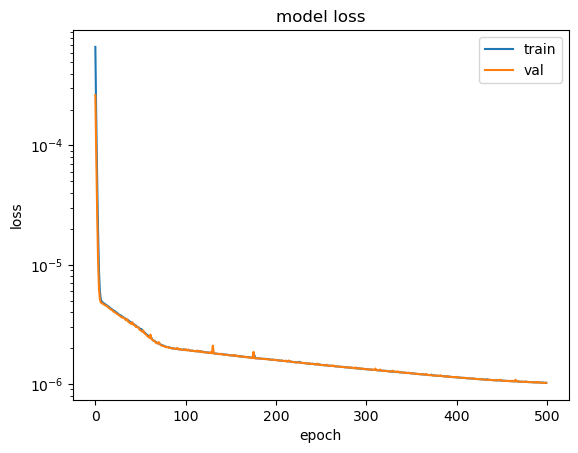

In [63]:
plt.plot(hist.history["loss"])
plt.plot(hist.history["val_loss"])
plt.title("model loss")
plt.ylabel("loss")
plt.xlabel("epoch")
plt.legend(["train", "val"])
plt.yscale("log")
np.set_printoptions(linewidth=np.inf)
layer = model.get_layer("log_rates")  # or model.layers[0]
weights, biases = layer.get_weights()

print("Exp Biases:", np.exp(biases))
weights = np.array(weights)
print("Weights:\n", weights)
results = np.matmul(test_arr, weights) + biases
x = np.array([[1, 0]] * 7).reshape(1, 7, 2)  # Template input
activation = Model(inputs=model.input, outputs=model.get_layer("log_rates").output)
activation_output = activation.predict(x)
print("Rates:", np.exp(activation_output))
y = model.predict(x)
print("Activity:", y)

In [64]:
# Regularize based on the rates with L1 norm on the exponent of the rate matrix
class LogRateL1SumRegularize(Regularizer):
    def __init__(self, coeff=1e-4):
        self.coeff = coeff

    def __call__(self, x):
        return self.coeff * tf.reduce_sum(tf.exp(x))

    def get_config(self):
        return {'coeff': float(self.coeff)}

inputs = layers.Input(shape=(seq_length, 2))  # one-hot encoded 'A'/'B' per position
flat = layers.Flatten()(inputs)  # flatten the input
log_rates = layers.Dense(
    7, activation="linear", name="log_rates", 
    kernel_regularizer=LogRateL1SumRegularize(1e-6), 
    bias_regularizer=LogRateL1SumRegularize(1e-6), 
    # activity_regularizer=LogRateL1SumRegularize(1e-6), 
    )(flat)  # hidden layer
KA_terms = layers.Lambda(
    lambda x: tf.nn.softmax(
        tf.matmul(x, tf.constant(ka_mat, dtype=tf.float32), transpose_b=True)
    ),
    name="KA_terms",
)(log_rates)
print(ka_mat.shape)
print(ka_contrib.shape)

# Corrected Lambda for contrib_KA_terms
contrib_KA_terms = layers.Lambda(
    lambda x: tf.matmul(x, tf.constant(ka_contrib, dtype=tf.float32), transpose_b=True),
    name="contrib_KA_terms",
)(KA_terms)
exp_rates = layers.Lambda(lambda x: tf.exp(x), name="exp_log_rates")(log_rates)
output = layers.Dot(axes=1, name="dot_output")([contrib_KA_terms, exp_rates])
model = Model(inputs=inputs, outputs=output)


model.compile(optimizer="adam", loss="mse")

# Train the model
hist = model.fit(
    x_train, y_train, epochs=500, batch_size=16, validation_data=(x_test, y_test)
)


(10, 7)
(7, 10)
Train on 1600 samples, validate on 400 samples
Epoch 1/500
1600/1600 [==============================] - 1s 451us/sample - loss: 0.0028 - val_loss: 0.0013
Epoch 2/500
1600/1600 [==============================] - 0s 54us/sample - loss: 0.0011 - val_loss: 6.6782e-04
Epoch 3/500
1600/1600 [==============================] - 0s 54us/sample - loss: 5.4909e-04 - val_loss: 3.6465e-04
Epoch 4/500
1600/1600 [==============================] - 0s 54us/sample - loss: 3.1269e-04 - val_loss: 2.3021e-04
Epoch 5/500
1600/1600 [==============================] - 0s 54us/sample - loss: 2.0790e-04 - val_loss: 1.7009e-04
Epoch 6/500
1600/1600 [==============================] - 0s 54us/sample - loss: 1.5924e-04 - val_loss: 1.4173e-04
Epoch 7/500
1600/1600 [==============================] - 0s 54us/sample - loss: 1.3571e-04 - val_loss: 1.2744e-04
Epoch 8/500
1600/1600 [==============================] - 0s 56us/sample - loss: 1.2399e-04 - val_loss: 1.2015e-04
Epoch 9/500
1600/1600 [=============

Exp Biases: [1.3236957  0.00337555 1.3254725  0.00348378 1.3216711  0.00327637 1.3251433 ]
Exp Weights:
 [[0.73243004 0.00330709 0.9454973  0.00336987 0.7569156  0.00314271 0.71260047]
 [0.59135926 0.0032671  0.3798081  0.00344325 0.5647934  0.00324385 0.6139597 ]
 [0.91341656 0.00332855 1.1040406  0.00342365 0.962884   0.00322077 0.7683179 ]
 [0.41020855 0.00305986 0.22126535 0.00325609 0.3585735  0.00301525 0.5570489 ]
 [0.81299573 0.00334726 0.8991215  0.00345797 0.8975759  0.00322175 0.7493547 ]
 [0.5108248  0.0031418  0.42609337 0.00327231 0.42392278 0.00305498 0.5769057 ]
 [1.0514969  0.00327787 1.0429739  0.00343254 1.0792614  0.00326432 0.8023661 ]
 [0.27195287 0.00328156 0.28220072 0.00333548 0.24203236 0.00303978 0.5229767 ]
 [0.8970613  0.00325789 0.8082687  0.00343291 0.9046558  0.0031947  0.75089157]
 [0.42669216 0.00333693 0.5170443  0.00337007 0.4168979  0.00322765 0.57514673]
 [1.1005621  0.00333639 0.90916234 0.00341979 0.97157276 0.00319559 0.7674398 ]
 [0.22341062 0.

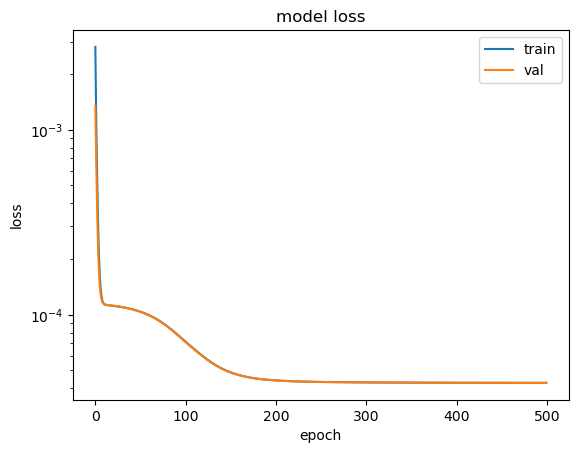

In [66]:
plt.plot(hist.history["loss"])
plt.plot(hist.history["val_loss"])
plt.title("model loss")
plt.ylabel("loss")
plt.xlabel("epoch")
plt.legend(["train", "val"])
plt.yscale("log")
np.set_printoptions(linewidth=np.inf)
layer = model.get_layer("log_rates")  # or model.layers[0]
weights, biases = layer.get_weights()

print("Exp Biases:", np.exp(biases))
weights = np.array(weights)
print("Exp Weights:\n", np.exp(weights))
results = np.matmul(test_arr, weights) + biases
x = np.array([[1, 0]] * 7).reshape(1, 7, 2)  # Template input
activation = Model(inputs=model.input, outputs=model.get_layer("log_rates").output)
activation_output = activation.predict(x)
print("Rates:", np.exp(activation_output))
y = model.predict(x)
print("Activity:", y)

In [77]:
# Regularize based on the rates with L1 norm on the exponent of the rate matrix

inputs = layers.Input(shape=(seq_length, 2))  # one-hot encoded 'A'/'B' per position
flat = layers.Flatten()(inputs)  # flatten the input
log_rates = layers.Dense(
    7, activation="linear", name="log_rates", 
    kernel_regularizer=regularizers.l1(1e-6), 
    # activity_regularizer=LogRateL1SumRegularize(1e-6), 
    )(flat)  # hidden layer
KA_terms = layers.Lambda(
    lambda x: tf.nn.softmax(
        tf.matmul(x, tf.constant(ka_mat, dtype=tf.float32), transpose_b=True)
    ),
    name="KA_terms",
)(log_rates)
print(ka_mat.shape)
print(ka_contrib.shape)

# Corrected Lambda for contrib_KA_terms
contrib_KA_terms = layers.Lambda(
    lambda x: tf.matmul(x, tf.constant(ka_contrib, dtype=tf.float32), transpose_b=True),
    name="contrib_KA_terms",
)(KA_terms)
exp_rates = layers.Lambda(lambda x: tf.exp(x), name="exp_log_rates")(log_rates)
output = layers.Dot(axes=1, name="dot_output")([contrib_KA_terms, exp_rates])
model = Model(inputs=inputs, outputs=output)


model.compile(optimizer="adam", loss="mse")

# Train the model
hist = model.fit(
    x_train, y_train, epochs=10, batch_size=1, validation_data=(x_test, y_test)
)


(10, 7)
(7, 10)
Train on 1600 samples, validate on 400 samples
Epoch 1/10
1600/1600 [==============================] - 2s 1ms/sample - loss: 5.2815e-04 - val_loss: 3.7428e-05
Epoch 2/10
1600/1600 [==============================] - 1s 803us/sample - loss: 2.9254e-05 - val_loss: 2.6757e-05
Epoch 3/10
1600/1600 [==============================] - 1s 837us/sample - loss: 2.6527e-05 - val_loss: 2.5510e-05
Epoch 4/10
1600/1600 [==============================] - 1s 796us/sample - loss: 2.5386e-05 - val_loss: 2.4555e-05
Epoch 5/10
1600/1600 [==============================] - 1s 801us/sample - loss: 2.3941e-05 - val_loss: 2.2616e-05
Epoch 6/10
1600/1600 [==============================] - 1s 809us/sample - loss: 2.1863e-05 - val_loss: 2.3866e-05
Epoch 7/10
1600/1600 [==============================] - 1s 775us/sample - loss: 1.9937e-05 - val_loss: 1.7724e-05
Epoch 8/10
1600/1600 [==============================] - 1s 780us/sample - loss: 1.7930e-05 - val_loss: 1.6144e-05
Epoch 9/10
1600/1600 [=====

Exp Biases: [0.8541684  1.2821438  0.87889165 1.193442   0.8649368  1.186775   0.8871876 ]
Weights:
 [[-3.04377675e-01 -1.12100528e-03  1.55705735e-01  3.41659546e-01  2.49275833e-01  4.45667863e-01  5.16729488e-04]
 [-8.25611353e-02  3.99553716e-01 -4.32514459e-01 -1.45882237e-04 -6.17445782e-02  8.61855894e-02  2.55311048e-03]
 [ 1.87043205e-01 -3.51534247e-01  3.22017670e-01 -1.13365741e-03 -2.93253899e-01  9.14475229e-03  2.65836832e-03]
 [-2.10972607e-01  1.32123493e-02 -5.27938940e-02  5.42730272e-01 -3.22611094e-03 -1.90381089e-03  1.40654563e-03]
 [ 1.35442764e-01 -1.03187142e-03 -2.02225521e-01 -5.60296476e-02  1.82546258e-01  4.86402549e-02  4.75687295e-04]
 [-3.51276815e-01  2.13153303e-01 -2.91729253e-02  1.06410362e-01 -2.91433819e-02 -1.06614409e-03  4.94948763e-04]
 [ 3.64539842e-03 -2.26651937e-01  2.13843718e-01  1.51386529e-01  5.12371004e-01  1.45516515e-01 -1.58006489e-01]
 [-1.12265619e-02  1.91075474e-01 -3.18523087e-02  8.35065320e-02 -3.39648843e-01  2.47725233e

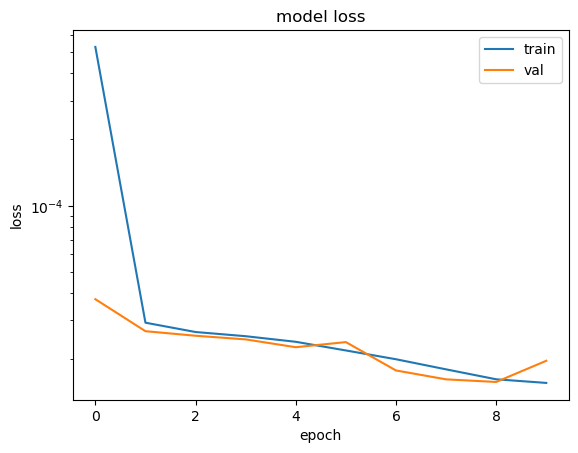

In [78]:
plt.plot(hist.history["loss"])
plt.plot(hist.history["val_loss"])
plt.title("model loss")
plt.ylabel("loss")
plt.xlabel("epoch")
plt.legend(["train", "val"])
plt.yscale("log")
np.set_printoptions(linewidth=np.inf)
layer = model.get_layer("log_rates")  # or model.layers[0]
weights, biases = layer.get_weights()

print("Exp Biases:", np.exp(biases))
weights = np.array(weights)
print("Weights:\n", weights)
print("Max weights:", np.max(weights.T, axis=1))
# print("Exp Weights:\n", np.exp(weights))
results = np.matmul(test_arr, weights) + biases
x = np.array([[1, 0]] * 7).reshape(1, 7, 2)  # Template input
activation = Model(inputs=model.input, outputs=model.get_layer("log_rates").output)
activation_output = activation.predict(x)
print("Rates:", np.exp(activation_output))
y = model.predict(x)
print("Activity:", y)

In [11]:
# Regularize based on entropy of the rate matrix
class ColumnEntropyRegularizer(Regularizer):
    def __init__(self, coeff=1e-3):
        self.coeff = coeff
    def __call__(self, W):
        P = tf.nn.softmax(W, axis=1)  # normalize rows
        entropy = -tf.reduce_sum(P * tf.math.log(P + 1e-8), axis=1)
        return self.coeff * tf.reduce_mean(entropy)

inputs = layers.Input(shape=(seq_length, 2))  # one-hot encoded 'A'/'B' per position
flat = layers.Flatten()(inputs)  # flatten the input
log_rates = layers.Dense(
    7, activation="linear", name="log_rates", 
    kernel_regularizer=ColumnEntropyRegularizer(1e-7), 
    )(flat)  # hidden layer
KA_terms = layers.Lambda(
    lambda x: tf.nn.softmax(
        tf.matmul(x, tf.constant(ka_mat, dtype=tf.float32), transpose_b=True)
    ),
    name="KA_terms",
)(log_rates)

# Corrected Lambda for contrib_KA_terms
contrib_KA_terms = layers.Lambda(
    lambda x: tf.matmul(x, tf.constant(ka_contrib, dtype=tf.float32), transpose_b=True),
    name="contrib_KA_terms",
)(KA_terms)
exp_rates = layers.Lambda(lambda x: tf.exp(x), name="exp_log_rates")(log_rates)
output = layers.Dot(axes=1, name="dot_output")([contrib_KA_terms, exp_rates])
model = Model(inputs=inputs, outputs=output)


model.compile(optimizer="adam", loss="mse")

# Train the model
hist = model.fit(
    x_train, y_train, epochs=500, batch_size=16, validation_data=(x_test, y_test)
)


Train on 1600 samples, validate on 400 samples
Epoch 1/500
1600/1600 [==============================] - 0s 264us/sample - loss: 0.0295 - val_loss: 0.0049
Epoch 2/500
1600/1600 [==============================] - 0s 68us/sample - loss: 0.0031 - val_loss: 0.0014
Epoch 3/500
1600/1600 [==============================] - 0s 69us/sample - loss: 0.0013 - val_loss: 8.7260e-04
Epoch 4/500
1600/1600 [==============================] - 0s 81us/sample - loss: 9.0160e-04 - val_loss: 6.6068e-04
Epoch 5/500
1600/1600 [==============================] - 0s 78us/sample - loss: 6.8996e-04 - val_loss: 5.1461e-04
Epoch 6/500
1600/1600 [==============================] - 0s 73us/sample - loss: 5.3280e-04 - val_loss: 3.9656e-04
Epoch 7/500
1600/1600 [==============================] - 0s 70us/sample - loss: 4.0476e-04 - val_loss: 2.9796e-04
Epoch 8/500
1600/1600 [==============================] - 0s 70us/sample - loss: 3.0183e-04 - val_loss: 2.2000e-04
Epoch 9/500
1600/1600 [==============================] - 0s 

Exp Biases: [0.87562674 1.0321203  0.91373587 1.0568508  0.8921227  1.2416447  0.8863035 ]
Weights:
 [[ 0.22969933 -0.2585851  -0.34663182  0.5132797  -0.00330762 -0.16187938  0.10181814]
 [-0.52980465 -0.12028319 -0.30944803 -0.05084225 -0.01089029  0.35031334  0.18457538]
 [-0.13394114 -0.4728141   0.3329005   0.42075    -0.29822004 -0.07516892  0.17770602]
 [-0.57009023  0.4468482  -0.07044349 -0.12499578 -0.01213355  0.29959127 -0.0459523 ]
 [ 0.22889294 -0.2217383   0.25069988  0.23819754  0.40086532  0.3177132   0.35743195]
 [ 0.39275855  0.40376267  0.02115883 -0.03059843  0.05857874 -0.17131545 -0.10817006]
 [-0.01891132  0.21138985 -0.27998474 -0.43982342 -0.05885917  0.06667942  0.16391051]
 [ 0.25105762  1.1251681   0.07462125  0.59745425 -0.12424178  0.3005161   0.05911041]
 [-0.15837197 -0.04554242  0.2887124   0.20571676  0.25726208 -0.11819834 -0.13554737]
 [-0.4502243  -0.366165    0.24561052  0.80028427  0.29453802  0.5269041   0.32546234]
 [ 0.10024375  0.17333981  0.

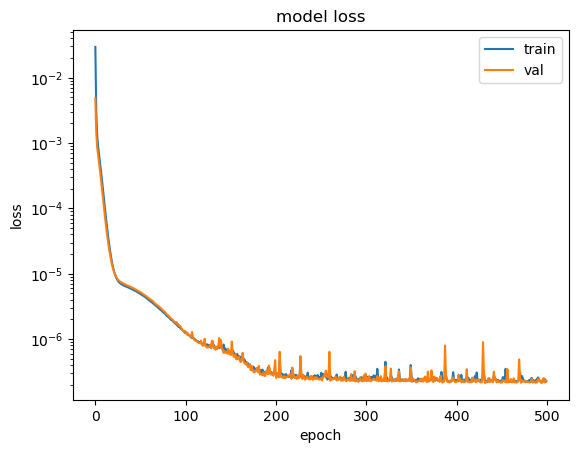

In [13]:
plt.plot(hist.history["loss"])
plt.plot(hist.history["val_loss"])
plt.title("model loss")
plt.ylabel("loss")
plt.xlabel("epoch")
plt.legend(["train", "val"])
plt.yscale("log")
np.set_printoptions(linewidth=np.inf)
layer = model.get_layer("log_rates")  # or model.layers[0]
weights, biases = layer.get_weights()

print("Exp Biases:", np.exp(biases))
weights = np.array(weights)
print("Weights:\n", weights)
print("Max weights:", np.max(weights, axis=1))
# print("Exp Weights:\n", np.exp(weights))
x = np.array([[1, 0]] * seq_length).reshape(1, seq_length, 2)  # Template input
activation = Model(inputs=model.input, outputs=model.get_layer("log_rates").output)
activation_output = activation.predict(x)
print("Matching Rates:", np.exp(activation_output))
y = model.predict(x)
print("Activity:", y)
xoff = x.copy()
xoff[:,0]=np.array([0,1])
print("Missmatching Rates:", np.exp(activation.predict(xoff)))
print("Missmatch activity:", model.predict(xoff))

In [ ]:
%load_ext watermark
%watermark -n -u -v -iv -w

Last updated: Fri Jul 04 2025

Python implementation: CPython
Python version       : 3.7.3
IPython version      : 7.33.0

numpy     : 1.18.5
scipy     : 1.5.3
matplotlib: 3.5.1
pandas    : 1.3.5
sklearn   : 1.0.2
tensorflow: 1.14.0
seaborn   : 0.12.2

Watermark: 2.5.0

